In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [2]:
df = pd.read_excel('data.xlsx')

In [3]:
## EDA
print(f"Cek 5 data teratas \n {df.head()} \n")

print(f"Cek missing values \n {df.isnull().sum()} \n")

print(f"Cek tipe data \n {df.dtypes}")

Cek 5 data teratas 
    NO                                         NAMA RUMAH       HARGA   LB  \
0   1  Rumah Murah Hook Tebet Timur, Tebet, Jakarta S...  3800000000  220   
1   2  Rumah Modern di Tebet dekat Stasiun, Tebet, Ja...  4600000000  180   
2   3  Rumah Mewah 2 Lantai Hanya 3 Menit Ke Tebet, T...  3000000000  267   
3   4           Rumah Baru Tebet, Tebet, Jakarta Selatan   430000000   40   
4   5  Rumah Bagus Tebet komp Gudang Peluru lt 350m, ...  9000000000  400   

    LT  KT  KM  GRS  
0  220   3   3    0  
1  137   4   3    2  
2  250   4   4    4  
3   25   2   2    0  
4  355   6   5    3   

Cek missing values 
 NO            0
NAMA RUMAH    0
HARGA         0
LB            0
LT            0
KT            0
KM            0
GRS           0
dtype: int64 

Cek tipe data 
 NO            int64
NAMA RUMAH      str
HARGA         int64
LB            int64
LT            int64
KT            int64
KM            int64
GRS           int64
dtype: object


In [4]:
if 'NO' in df.columns:
    df.drop(columns=['NO'], inplace=True)

In [5]:
import numpy as np

df = df.select_dtypes(include=np.number)

In [6]:
print(df.dtypes)

HARGA    int64
LB       int64
LT       int64
KT       int64
KM       int64
GRS      int64
dtype: object


In [7]:
df.fillna(df.median(numeric_only=True), inplace=True)

,HARGA,LB,LT,KT,KM,GRS
0,3800000000,220,220,3,3,0
1,4600000000,180,137,4,3,2
2,3000000000,267,250,4,4,4
3,430000000,40,25,2,2,0
4,9000000000,400,355,6,5,3
...,...,...,...,...,...,...
1005,9000000000,450,550,10,10,3
1006,4000000000,160,140,4,3,2
1007,4000000000,139,230,4,4,1
1008,19000000000,360,606,7,4,0


In [8]:
num_cols = df.columns

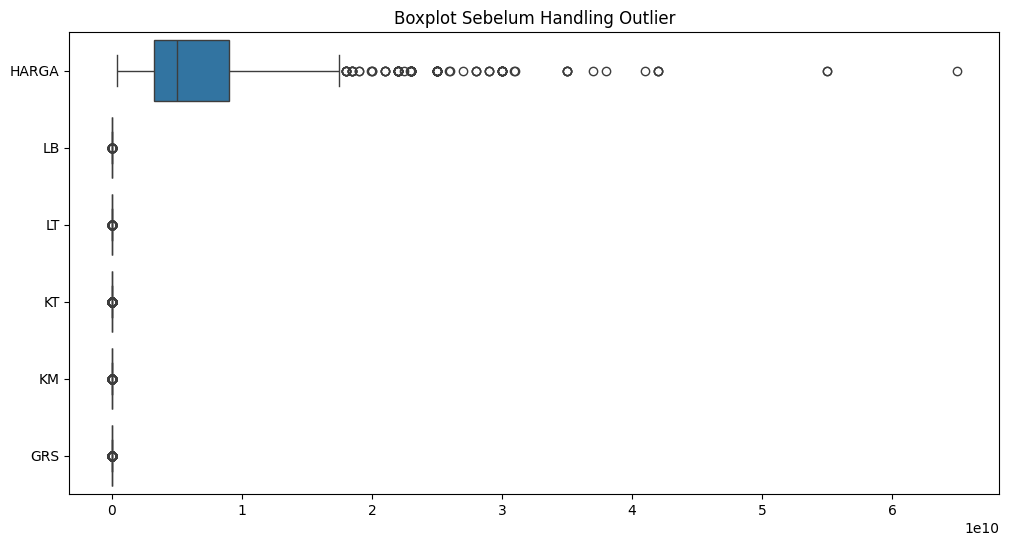

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols], orient='h')
plt.title('Boxplot Sebelum Handling Outlier')
plt.show()

In [10]:
df_handled = df.copy()
for col in num_cols:
    Q1 = df_handled[col].quantile(0.25)
    Q3 = df_handled[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_handled[col] = df_handled[col].clip(lower, upper)

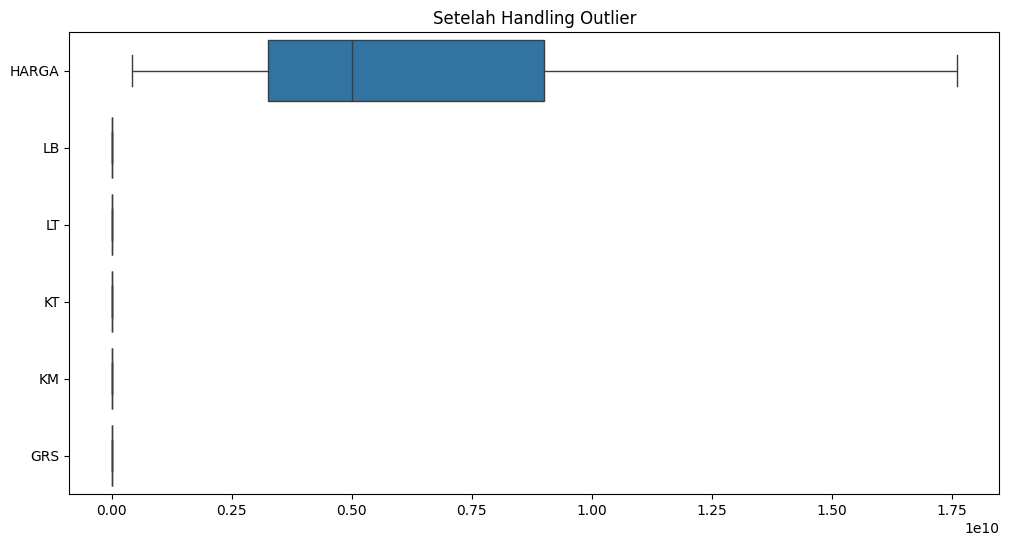

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_handled[num_cols], orient='h')
plt.title('Setelah Handling Outlier')
plt.show()

In [12]:
df_handled['TOTAL_RUANG'] = (
    df_handled['KT'] +
    df_handled['KM']
)

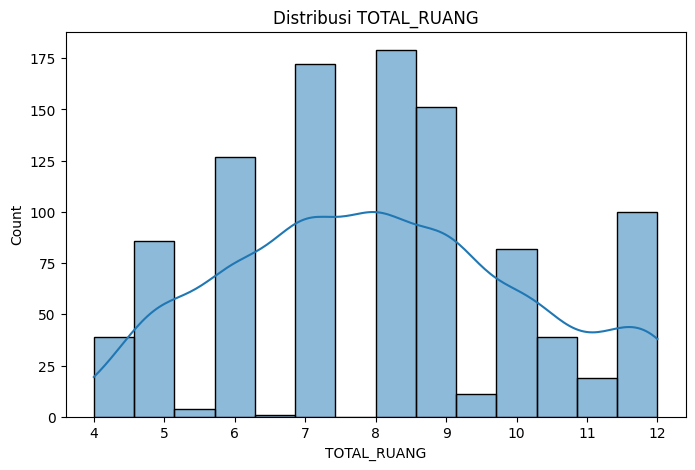

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_handled['TOTAL_RUANG'],
    kde=True
)

plt.title('Distribusi TOTAL_RUANG')

plt.show()

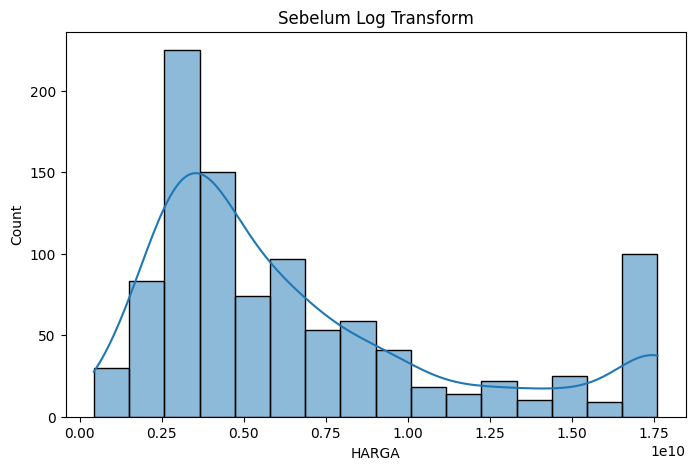

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_handled['HARGA'],
    kde=True
)

plt.title('Sebelum Log Transform')

plt.show()

In [15]:
df_handled['HARGA'] = np.log1p(
    df_handled['HARGA']
)

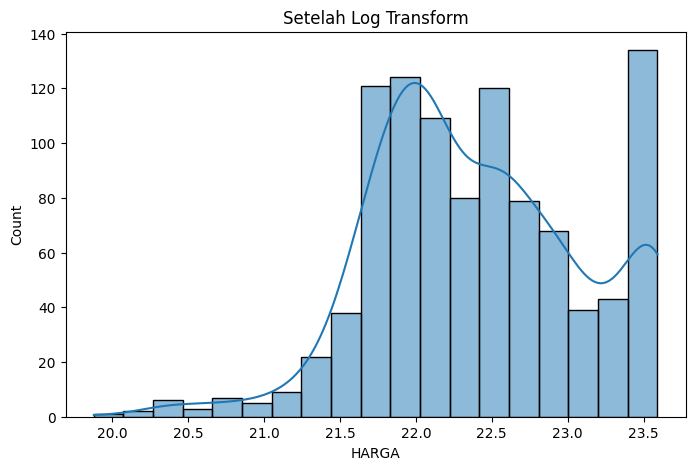

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_handled['HARGA'],
    kde=True
)

plt.title('Setelah Log Transform')

plt.show()

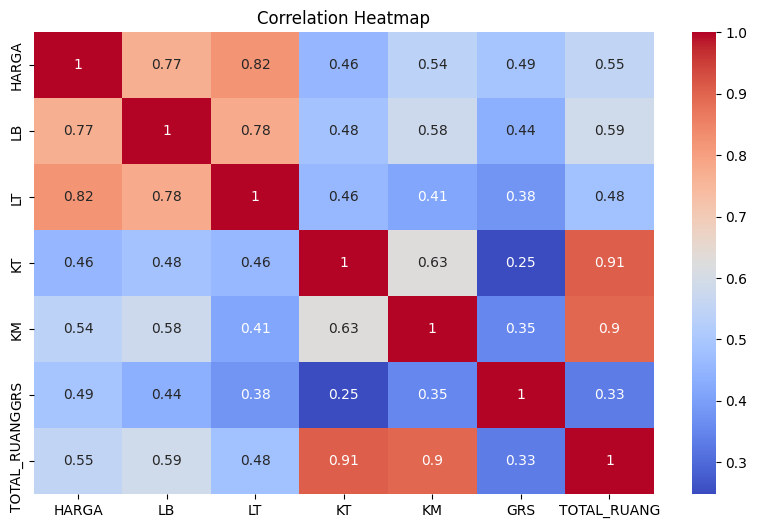

In [17]:
plt.figure(figsize=(10,6))
corr = df_handled.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

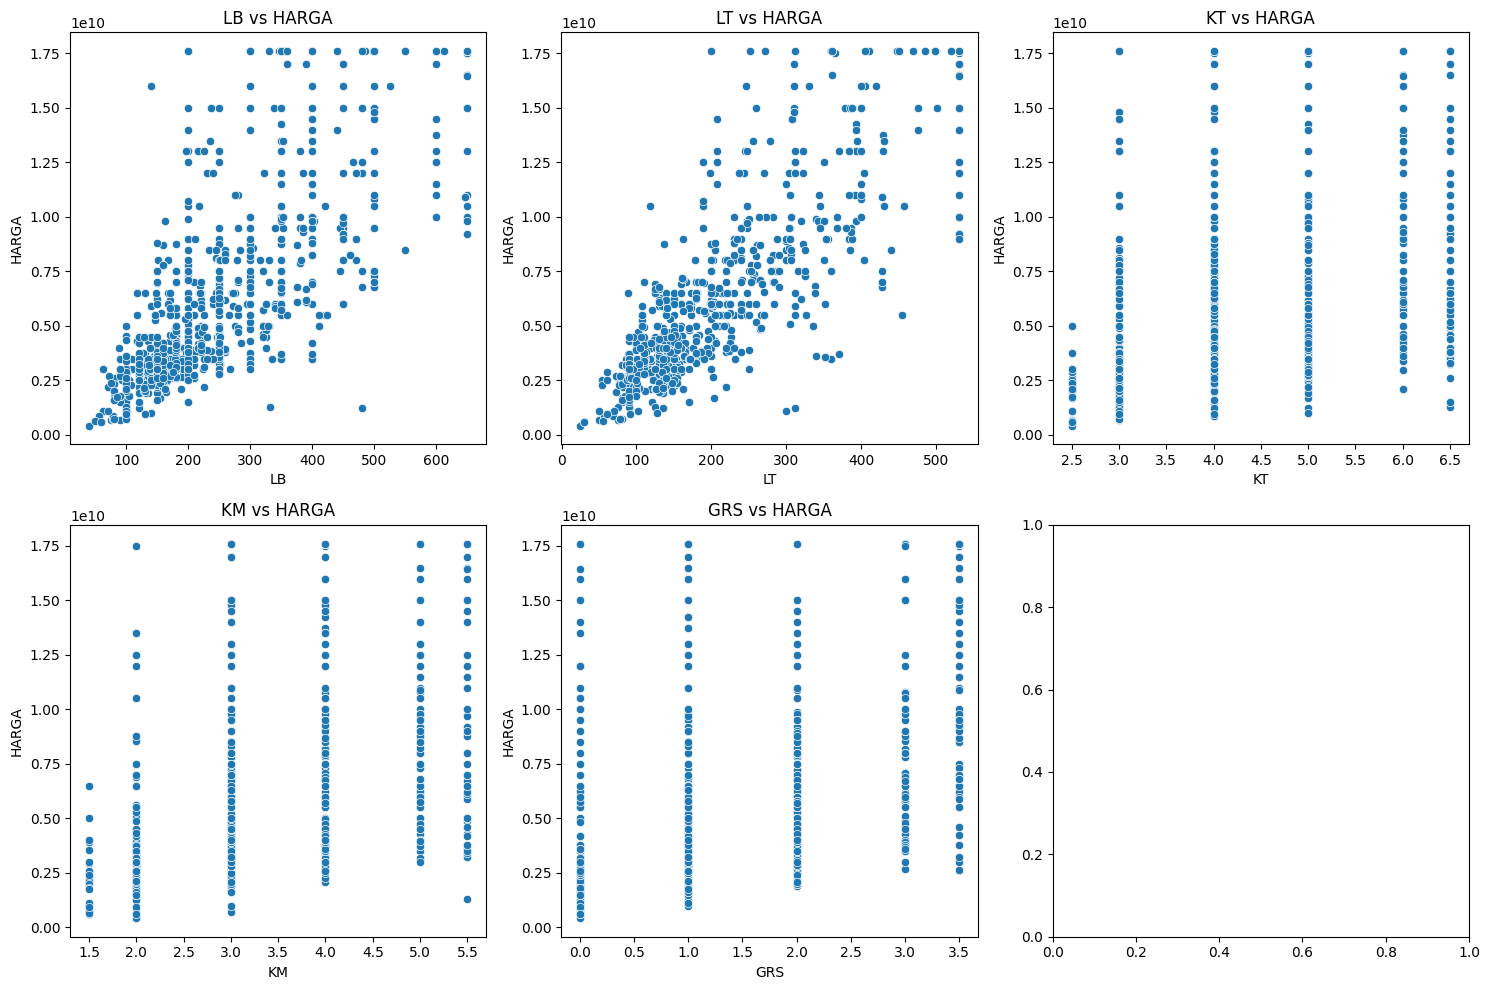

In [18]:
fitur = ['LB', 'LT', 'KT', 'KM', 'GRS']

fig, axes = plt.subplots(2, 3, figsize=(15,10))

axes = axes.flatten()

for i, col in enumerate(fitur):

    sns.scatterplot(
        x=df_handled[col],
        y=np.expm1(df_handled['HARGA'])
,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs HARGA')

plt.tight_layout()
plt.show()

In [19]:
X = df_handled.drop('HARGA', axis=1)

y = df_handled['HARGA']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

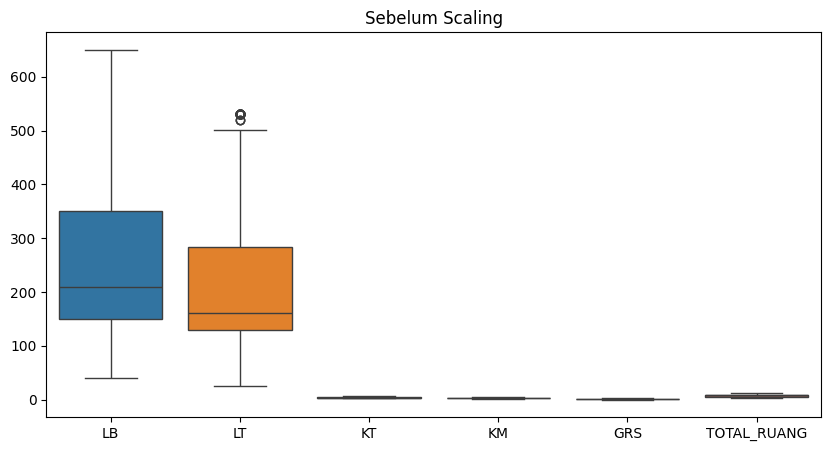

In [22]:
plt.figure(figsize=(10,5))

sns.boxplot(data=X_train)

plt.title('Sebelum Scaling')

plt.show()

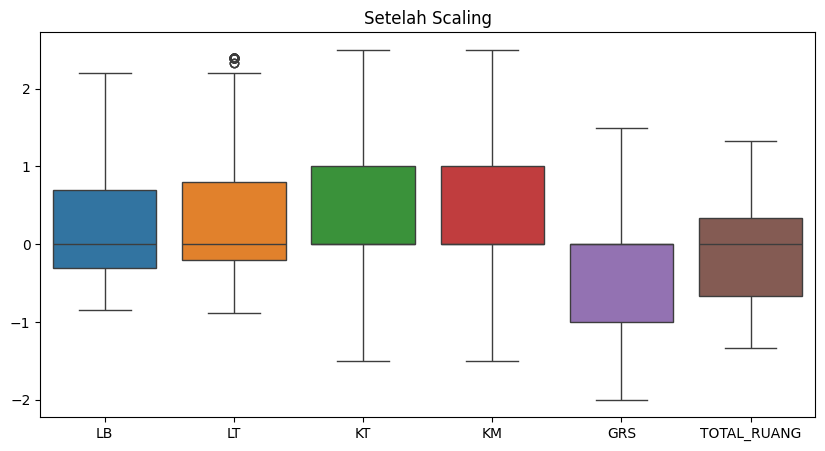

In [23]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=pd.DataFrame(
        X_train_scaled,
        columns=X.columns
    )
)

plt.title('Setelah Scaling')

plt.show()

In [24]:
model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_pred = model.predict(
    X_test_scaled
)

In [26]:
mae_asli = mean_absolute_error(
    np.expm1(y_test),
    np.expm1(y_pred)
)

print('MAE Rupiah :', mae_asli)

MAE Rupiah : 1723828015.3922665


In [27]:
rmse_asli = np.sqrt(
    mean_squared_error(
        np.expm1(y_test),
        np.expm1(y_pred)
    )
)

print('RMSE Rupiah :', rmse_asli)

RMSE Rupiah : 2681856086.8050966


In [28]:
r2 = r2_score(
    y_test,
    y_pred
)

print('R2 Score :', r2)

R2 Score : 0.7869927164156427


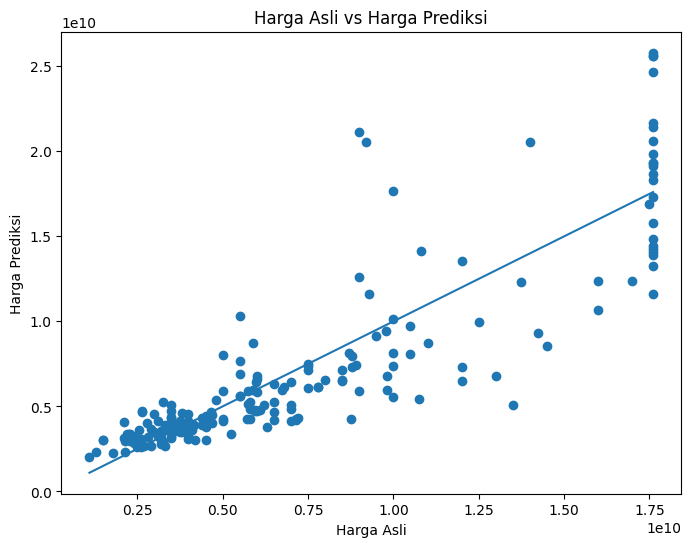

In [29]:
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

plt.figure(figsize=(8,6))

plt.scatter(y_test_real, y_pred_real)

plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
)

plt.xlabel('Harga Asli')
plt.ylabel('Harga Prediksi')

plt.title('Harga Asli vs Harga Prediksi')

plt.show()

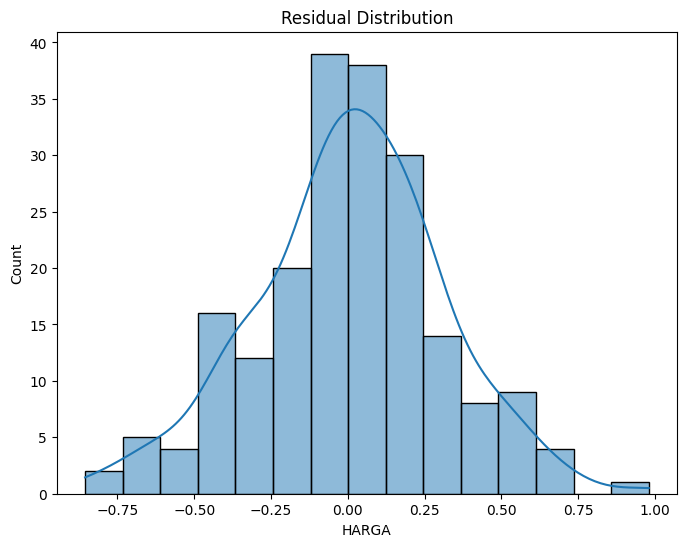

In [30]:
residual = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(
    residual,
    kde=True
)

plt.title('Residual Distribution')

plt.show()

In [31]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coef_df)

       Feature  Coefficient
0           LB     0.146171
1           LT     0.462843
2           KT    -0.022679
3           KM     0.106562
4          GRS     0.090541
5  TOTAL_RUANG     0.027961


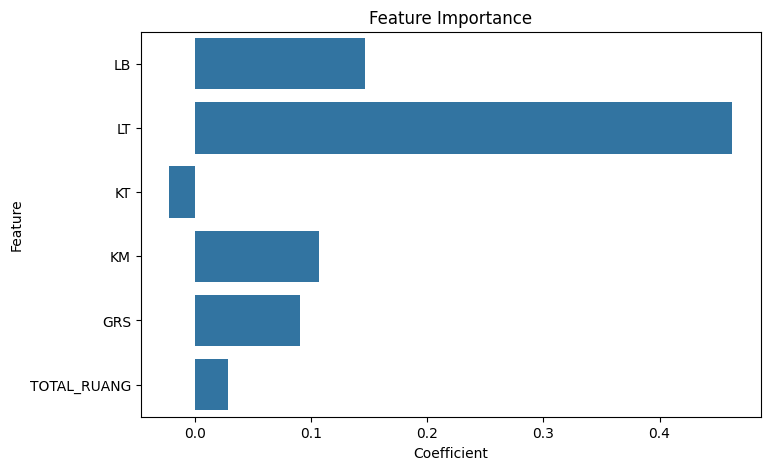

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=coef_df['Coefficient'],
    y=coef_df['Feature']
)

plt.title('Feature Importance')

plt.show()

In [39]:
# =========================
# DATA RUMAH BARU
# =========================
rumah_baru = pd.DataFrame({

    'LB': [300],
    'LT': [265],
    'KT': [4],
    'KM': [3],
    'GRS': [0],
    'TOTAL_RUANG': [7],

})

# =========================
# SCALING
# =========================
rumah_baru_scaled = scaler.transform(rumah_baru)

# =========================
# PREDIKSI
# =========================
prediksi_log = model.predict(rumah_baru_scaled)

# =========================
# KEMBALIKAN KE HARGA ASLI
# =========================
harga_asli = np.expm1(prediksi_log)[0]

# =========================
# FORMAT M / JT
# =========================
if harga_asli >= 1_000_000_000:
    hasil = f"{harga_asli/1_000_000_000:.2f} M"

else:
    hasil = f"{harga_asli/1_000_000:.2f} JT"

print("Prediksi Harga Rumah :",hasil)

Prediksi Harga Rumah : 5.05 M


In [40]:
import pickle

# save model
pickle.dump(
    model,
    open('model_rumah.pkl', 'wb')
)

# save scaler
pickle.dump(
    scaler,
    open('scaler.pkl', 'wb')
)

print("Model dan scaler berhasil disimpan")

Model dan scaler berhasil disimpan
